## Data & Packages

In [1]:
# Packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Optimisation packages
from scipy.optimize import linear_sum_assignment

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24
eight_weeks_seconds = 8 * 7 * seconds_in_day

# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

In [5]:
# Keep the first 8 weeks of data
df = df.filter(pl.col("time") <= eight_weeks_seconds)

In [6]:
# Chosen features
feature_cols = [
    'log_n_events',
    'log_n_distinct_src',
    'log_n_distinct_dest',
    'failure_ratio',
    'c_bar',
    's_bar',
    ]

## Functions

In [7]:
# Build the features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60 

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
            log_n_events = pl.col('n_events').log(),
            log_n_distinct_src = pl.col('n_distinct_src').log(),
            log_n_distinct_dest = pl.col('n_distinct_dest').log(),
        ).collect()
        )

In [8]:
# Process features for clustering
def cluster_preprocess(features_df, X_scaled, week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    in_bin = features_df['bucket'].is_between(lb,ub).to_numpy()

    features_week = features_df.filter(in_bin)
    X_scaled_week = X_scaled[in_bin]

    return features_week, X_scaled_week 

## Clustering

In [ ]:
# Build the features dataframe
features_df = build_features(df, agg_hour_level)

In [10]:
# Standardise features
X = features_df.select(feature_cols).to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
# Cluster for each week 
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled_week = cluster_preprocess(features_df,X_scaled, week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(X_scaled_week)

    features_week = (features_week.with_columns(pl.Series('cluster',labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

## Label Matching

In [ ]:
# Label matching using JACARD index (and hungarian algorithm to solve the optimisation)
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

# Cluster Stability Metrics

In [59]:
d = aligned_labels[1]

stayed = (d['labels_curr'] == d['labels_next'])

keys = pl.DataFrame({
    'src_user':        d['src_user'],
    'relative_bucket': d['relative_bucket'],
})

stayed_set = keys.filter(pl.Series(stayed))
moved_set  = keys.filter(pl.Series(~stayed))

print(f"Stayed: {stayed_set.height}")
print(f"Moved:  {moved_set.height}")

Stayed: 288045
Moved:  327579


In [62]:
d = aligned_labels[1]
stayed = d['labels_curr'] == d['labels_next']

week = 1
lb = (week - 1) * buckets_per_week        # 0 for week 1

stayed_keys = pl.DataFrame({
    'src_user': d['src_user'][stayed],
    'bucket':   d['relative_bucket'][stayed] + lb,   # back to absolute
})

# Attach the row number, then match on the key
features_idx = features_df.with_row_index('row_nr')

matched = stayed_keys.join(features_idx, on=['src_user', 'bucket'], how='inner')

rows = matched['row_nr'].to_numpy()
X_stayed = X_scaled[rows]

print(X_stayed.shape)   # (n_stayed, n_features)

(288045, 6)


In [63]:
d = aligned_labels[1]
stayed = d['labels_curr'] == d['labels_next']

w1, w2 = 1, 2
lb1 = (w1 - 1) * buckets_per_week
lb2 = (w2 - 1) * buckets_per_week

# One row per stayed point, carrying a stable id so both weeks stay aligned
stayed_keys = pl.DataFrame({
    'pair_id':  np.arange(stayed.sum()),
    'src_user': d['src_user'][stayed],
    'rel':      d['relative_bucket'][stayed],
})

features_idx = features_df.with_row_index('row_nr')

def rows_for(bucket_offset):
    q = (
        stayed_keys
        .with_columns(bucket=pl.col('rel') + bucket_offset)
        .join(features_idx, on=['src_user', 'bucket'], how='inner')
        .sort('pair_id')                      # realign to the stable order
    )
    return q

m1 = rows_for(lb1)
m2 = rows_for(lb2)

X_w1 = X_scaled[m1['row_nr'].to_numpy()]
X_w2 = X_scaled[m2['row_nr'].to_numpy()]

print(X_w1.shape, X_w2.shape)

(288045, 6) (288045, 6)


In [87]:
delta = X_w2 - X_w1
delta = delta[:,:-2]

In [91]:
keep = [i for i, c in enumerate(feature_cols) if c not in ('c_bar', 's_bar')]

# difference in the (log or raw) feature space, un-standardised
delta_transformed = delta * scaler.scale_[keep]

In [93]:
delta_transformed

array([[ 0.67015766,  0.22314355,  0.40546511,  0.        ],
       [-0.02666825, -0.28768207, -0.5389965 ,  0.        ],
       [-0.06453852,  0.        ,  0.40546511,  0.        ],
       ...,
       [-0.07275935, -0.13353139, -0.11778304,  0.        ],
       [ 0.85221188,  0.40546511,  0.58778666,  0.01470588],
       [ 0.69314718,  0.55961579,  1.09861229,  0.        ]],
      shape=(288045, 4))

In [102]:
raw_cols = ['n_events', 'n_distinct_src', 'n_distinct_dest', 'failure_ratio']

# m1, m2 already sorted by pair_id and carry the same pair set in the same order
raw_w1 = m1.select(raw_cols).to_numpy()
raw_w2 = m2.select(raw_cols).to_numpy()

raw_delta = raw_w2 - raw_w1   # change in true units, row i = pair_id i

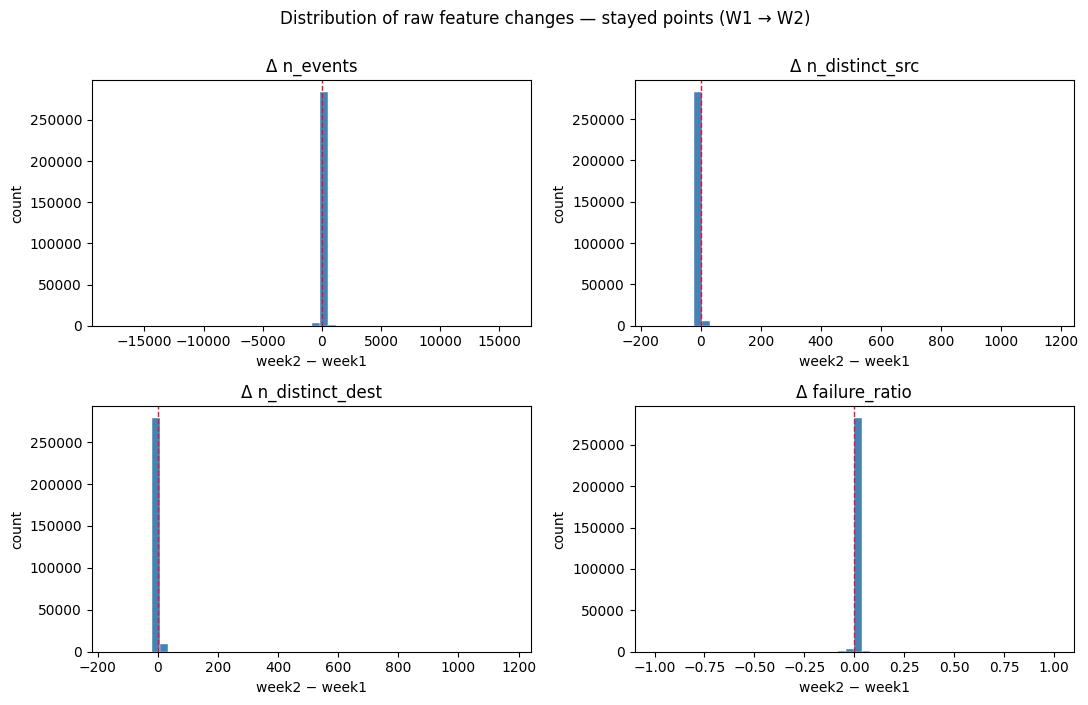

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col, vals in zip(axes.flat, raw_cols, raw_delta.T):
    ax.hist(vals, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(f'Δ {col}')
    ax.set_xlabel('week2 − week1')
    ax.set_ylabel('count')

fig.suptitle('Distribution of raw feature changes — stayed points (W1 → W2)', y=1.0)
plt.tight_layout()
plt.show()

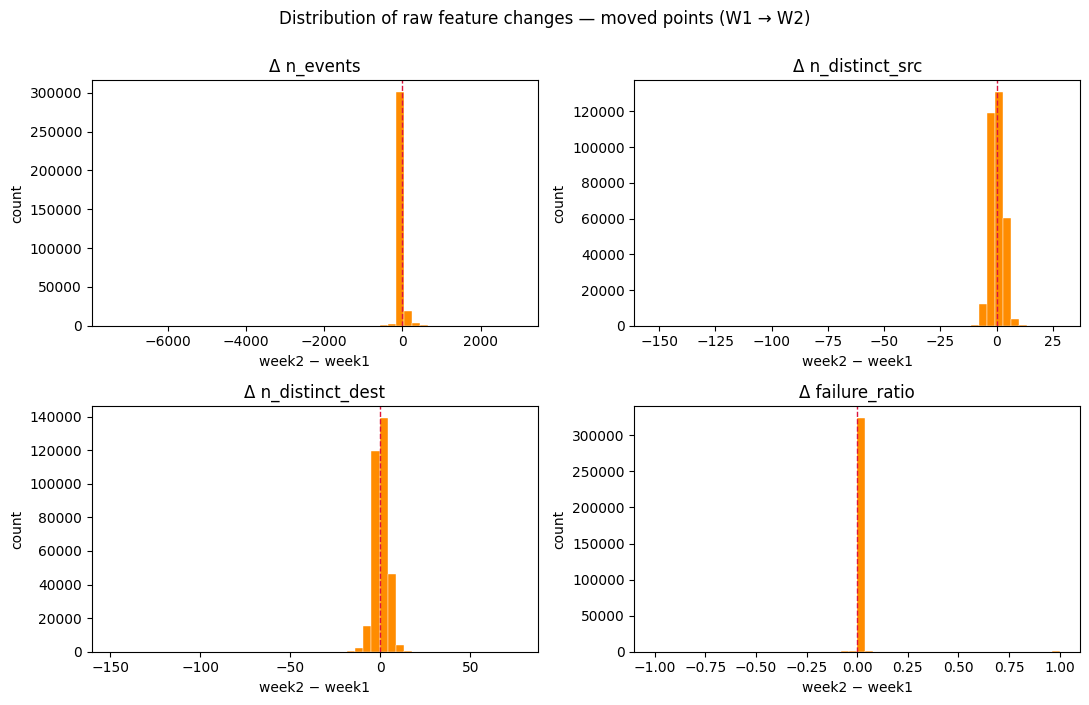

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

for ax, col, vals in zip(axes.flat, raw_cols, raw_delta_moved.T):
    ax.hist(vals, bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='crimson', linestyle='--', linewidth=1)
    ax.set_title(f'Δ {col}')
    ax.set_xlabel('week2 − week1')
    ax.set_ylabel('count')

fig.suptitle('Distribution of raw feature changes — moved points (W1 → W2)', y=1.0)
plt.tight_layout()
plt.show()